<a href="https://colab.research.google.com/github/AliRaddman/ai-bootcamp-DeepLearning/blob/main/04_nlp_deep_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Review Rating Prediction with DistilBERT

## Project Overview
The goal of this project is to predict the overall product rating (`overall`) from Amazon review data using Natural Language Processing (NLP).

This is a **multi-class text classification** problem where the target variable has five possible classes: **1, 2, 3, 4, and 5**.

To solve this task, we fine-tune the pretrained transformer model **`distilbert-base-uncased`**. The model learns from review-related textual information and predicts the most likely rating for each sample.

## Main Workflow
The project follows these main steps:

1. Load and inspect the training and test datasets  
2. Clean and prepare the text features  
3. Combine multiple text fields into a single model input  
4. Analyze the target class distribution  
5. Tokenize the text using the DistilBERT tokenizer  
6. Convert the data into a format suitable for model training  
7. Configure the model and training pipeline  
8. Fine-tune the model and evaluate it on validation data  
9. Save the best model  
10. Generate predictions for the test set  
11. Create the final `submission.csv` file  
12. Analyze the final results and summarize the project  

## Evaluation Metrics
The model is evaluated using the following metrics:

- **Accuracy**: the proportion of correct predictions among all samples  
- **Macro F1-score**: the average F1-score across all classes with equal weight  
- **Weighted F1-score**: the average F1-score weighted by the number of samples in each class  

Because class imbalance may exist in rating prediction tasks, relying only on accuracy is not sufficient. Therefore, Macro F1-score is also used to better assess performance across all classes.


##  Importing Required Libraries

This section imports the libraries required for data handling, reproducibility, class-imbalance handling, model training, evaluation, and file management.

- **NumPy** and **Pandas** are used for numerical operations and data manipulation.
- **PyTorch** provides the deep learning framework and GPU support.
- **Hugging Face Datasets** and **Transformers** are used to prepare text data and fine-tune the DistilBERT model.
- **Scikit-learn** provides class-weight computation and evaluation metrics.
- **Google Drive** is used to access input data and persist model artifacts, checkpoints, metrics, and submission files in Google Colab.


In [ ]:
# ==============================================================================
# Deep Sentiment: End-to-End Training + Validation + Submission
# ==============================================================================

import os
import gc
import random
import torch
import numpy as np
import pandas as pd

from torch import nn
from google.colab import drive
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

## 1. Environment Verification and Reproducibility

Before training, the versions of the main machine learning libraries are recorded to document the execution environment.

A fixed random seed (`42`) is applied to Python, NumPy, and PyTorch. This improves experiment reproducibility by reducing randomness in data-related and model-training operations.

The notebook also checks whether a CUDA-enabled GPU is available. GPU acceleration is important for efficient fine-tuning of transformer-based language models.


In [ ]:

# ==============================================================================
# Step 1: Version Check and Reproducibility Setup
# ==============================================================================

import transformers
import datasets
import accelerate

print("[INFO] Library versions:")
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)

# Set a global seed for reproducible results
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n[INFO] Using device: {device}")

if not torch.cuda.is_available():
    print("[WARNING] CUDA is not available. Training on CPU will be very slow.")

[INFO] Library versions:
transformers: 5.13.1
datasets: 4.0.0
accelerate: 1.14.0

[INFO] Using device: cuda


**Output summary:** CUDA GPU support was detected successfully, so the DistilBERT model can be fine-tuned using hardware acceleration. The library versions were recorded to improve experiment traceability and reproducibility.


## 2. Experiment Configuration

This section defines the main configuration for the DistilBERT fine-tuning experiment.

The pretrained `distilbert-base-uncased` model is used for five-class review rating prediction. The maximum token length, batch size, learning rate, and total number of epochs are specified here.

The full training and validation datasets are used because both `LIMIT_TRAIN` and `LIMIT_VALIDATION` are set to `None`. The checkpoint from the end of epoch 2 is provided so that training can resume from its saved state rather than starting from scratch.

Input and output paths are also defined centrally to load the cleaned datasets and save all resulting artifacts consistently.
# New Section

In [ ]:
# ==============================================================================
# Step 2: Configuration
# ==============================================================================

MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 192
BATCH_SIZE = 8
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

# None means use the complete dataset
LIMIT_TRAIN = None
LIMIT_VALIDATION = None

RESUME_CHECKPOINT = "/content/drive/MyDrive/AI_Project2 (1)/outputs/deep_sentiment/checkpoint_runs/checkpoint-166114"

INPUT_DIR = "/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp"
OUTPUT_DIR = "/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp"

TRAIN_PATH = os.path.join(INPUT_DIR, "nlp_train_clean.csv")
VALID_PATH = os.path.join(INPUT_DIR, "nlp_validation_clean.csv")
TEST_PATH = os.path.join(INPUT_DIR, "nlp_test_clean.csv")

## 3. Google Drive Mounting and Input Validation

Google Drive is mounted to access the cleaned training, validation, and test datasets, as well as to persist project outputs.

The output directory is created if it does not already exist. The notebook then verifies that all required CSV files are available before continuing. This validation step prevents later failures caused by incorrect paths or missing input files.


In [ ]:
# ==============================================================================
# Step 3: Mount Google Drive and Validate Paths
# ==============================================================================

print("\n[INFO] Mounting Google Drive...")
drive.mount("/content/drive", force_remount=False)

# Create the output directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Check that all required files are available
for file_path in [TRAIN_PATH, VALID_PATH, TEST_PATH]:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Required file was not found:\n{file_path}")

print("[INFO] All input files were found successfully.")


[INFO] Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] All input files were found successfully.


## 4. Loading the Cleaned Datasets

The cleaned training, validation, and test CSV files are loaded from Google Drive.

To ensure compatibility with the available files, the notebook automatically selects `reviewText_clean` when it exists; otherwise, it falls back to the original `reviewText` column. The selected text column is then renamed to `review_text` to provide a consistent name for downstream processing.

Only the columns required for the modeling pipeline are loaded:

- `row_id`: unique identifier used for tracking samples and creating the final submission file.
- `review_text`: cleaned review content used as the main textual input.
- `title`: product title, used as supplementary context.
- `brand`: product brand, used as supplementary context.
- `overall`: review rating target, available only in the training and validation datasets.

Optional row limits are included for debugging purposes, but they are disabled in the final experiment because both limits are set to `None`.


In [ ]:
# ==============================================================================
# Step 4: Load Data
# ==============================================================================

def get_available_columns(csv_path):
    """Return column names without loading the entire CSV file."""
    return pd.read_csv(csv_path, nrows=0).columns.tolist()


def get_text_column(csv_path):
    """Prefer reviewText_clean, otherwise use reviewText."""
    available_columns = get_available_columns(csv_path)

    if "reviewText_clean" in available_columns:
        return "reviewText_clean"

    if "reviewText" in available_columns:
        return "reviewText"

    raise ValueError(
        f"Neither 'reviewText_clean' nor 'reviewText' exists in:\n{csv_path}"
    )


# Detect the appropriate review-text field independently for each dataset
train_review_column = get_text_column(TRAIN_PATH)
valid_review_column = get_text_column(VALID_PATH)
test_review_column = get_text_column(TEST_PATH)

# Define columns required from each dataset
train_columns = ["row_id", train_review_column, "title", "brand", "overall"]
valid_columns = ["row_id", valid_review_column, "title", "brand", "overall"]
test_columns = ["row_id", test_review_column, "title", "brand"]

print("\n[INFO] Loading CSV files...")

train_df = pd.read_csv(TRAIN_PATH, usecols=train_columns)
valid_df = pd.read_csv(VALID_PATH, usecols=valid_columns)
test_df = pd.read_csv(TEST_PATH, usecols=test_columns)

# Normalize all review text column names for easier downstream processing
train_df = train_df.rename(columns={train_review_column: "review_text"})
valid_df = valid_df.rename(columns={valid_review_column: "review_text"})
test_df = test_df.rename(columns={test_review_column: "review_text"})

print(f"Train shape before preprocessing: {train_df.shape}")
print(f"Validation shape before preprocessing: {valid_df.shape}")
print(f"Test shape before preprocessing: {test_df.shape}")

# Apply optional debugging limits only when configured
if LIMIT_TRAIN is not None:
    train_df = train_df.iloc[:LIMIT_TRAIN].copy()
    print(f"[DEBUG] Train dataset limited to {len(train_df):,} rows.")

if LIMIT_VALIDATION is not None:
    valid_df = valid_df.iloc[:LIMIT_VALIDATION].copy()
    print(f"[DEBUG] Validation dataset limited to {len(valid_df):,} rows.")



[INFO] Loading CSV files...
Train shape before preprocessing: (664451, 5)
Validation shape before preprocessing: (166161, 5)
Test shape before preprocessing: (20000, 4)


**Output summary:** The datasets were loaded successfully. The training set contains 664,451 labeled reviews, the validation set contains 166,161 labeled reviews, and the test set contains 20,000 unlabeled reviews for final prediction.


## 5. Text and Label Preparation

This step prepares the datasets for transformer-based sentiment classification.

Missing values in the review text, product title, and brand fields are replaced with empty strings. These fields are then combined into a single `formatted_text` feature, allowing DistilBERT to use both review content and product-level context.

The final text format is:
```text
Product title: <title> Brand: <brand> Review: <review_text>


In [ ]:
# ==============================================================================
# Step 5: Text Preparation and Label Preparation
# ==============================================================================

def prepare_dataframe(df, is_test=False):
    """
    Clean text-related fields and create a unified formatted_text feature.

    For train/validation:
    - Remove invalid rating values.
    - Convert ratings 1..5 into labels 0..4.

    For test:
    - Keep every row because each row requires a submission prediction.
    """
    df = df.copy()

    # Replace missing values with empty strings
    df["review_text"] = df["review_text"].fillna("").astype(str)
    df["title"] = df["title"].fillna("").astype(str)
    df["brand"] = df["brand"].fillna("").astype(str)

    # Create a single textual input for DistilBERT
    df["formatted_text"] = (
        "Product title: " + df["title"] +
        " Brand: " + df["brand"] +
        " Review: " + df["review_text"]
    )

    if not is_test:
        # Keep only ratings in the valid 1..5 range
        df = df[df["overall"].between(1, 5)].copy()

        # Remove rows where every textual field is empty
        has_any_text = (
            df["review_text"].str.strip().ne("") |
            df["title"].str.strip().ne("") |
            df["brand"].str.strip().ne("")
        )
        df = df[has_any_text].copy()

        # Convert rating classes from 1..5 into labels 0..4
        df["label"] = df["overall"].astype(int) - 1

    return df


print("\n[INFO] Preparing text and labels...")

train_df = prepare_dataframe(train_df, is_test=False)
valid_df = prepare_dataframe(valid_df, is_test=False)
test_df = prepare_dataframe(test_df, is_test=True)

print(f"Train shape after preprocessing: {train_df.shape}")
print(f"Validation shape after preprocessing: {valid_df.shape}")
print(f"Test shape after preprocessing: {test_df.shape}")

# Ensure every rating class exists in training data
expected_labels = set(range(5))
observed_labels = set(train_df["label"].unique())

if observed_labels != expected_labels:
    raise ValueError(
        f"Training labels must contain all classes 0..4.\n"
        f"Observed labels: {sorted(observed_labels)}"
    )


[INFO] Preparing text and labels...
Train shape after preprocessing: (664451, 7)
Validation shape after preprocessing: (166161, 7)
Test shape after preprocessing: (20000, 5)


**Output summary:** All datasets were prepared successfully. No records were removed during validation, the textual fields were combined into a unified transformer input, and the training data contains all five rating classes.


## 6. Handling Class Imbalance with Class Weights

The rating classes are imbalanced, with high ratings—especially rating 5—occurring much more frequently than low and middle ratings.

To reduce bias toward the majority class, balanced class weights are computed from the training labels using Scikit-learn's `compute_class_weight` function. Each class weight is inversely related to its frequency:

- Minority classes receive larger weights.
- Majority classes receive smaller weights.
- Misclassifying an underrepresented rating therefore contributes more strongly to the training loss.

The weights are converted to a PyTorch tensor and placed on the active compute device so they can be passed to the weighted cross-entropy loss function during model training.


In [ ]:

# ==============================================================================
# Step 6: Compute Class Weights
# ==============================================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(5),
    y=train_df["label"].values
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("\n[INFO] Class weights:")
for label, weight in enumerate(class_weights, start=1):
    print(f"Rating {label}: {weight:.4f}")


[INFO] Class weights:
Rating 1: 2.0144
Rating 2: 2.9625
Rating 3: 2.0641
Rating 4: 1.0681
Rating 5: 0.3643


**Output summary:** Class weights were computed successfully. Rating 2 received the highest weight because it is the least frequent class, while rating 5 received the lowest weight because it is the dominant class.


## 7. Creating Hugging Face Datasets and Tokenization

The prepared pandas DataFrames are converted into Hugging Face `Dataset` objects, which provide efficient integration with the Transformers training pipeline.

The tokenizer associated with `distilbert-base-uncased` converts each `formatted_text` sample into numerical token representations. Tokenization applies:

- **Truncation:** inputs longer than `MAX_LENGTH` tokens are truncated.
- **Maximum sequence length:** each sequence is limited to `MAX_LENGTH`.
- **Dynamic padding:** padding is applied only up to the longest sequence within each mini-batch, rather than padding every sample to the global maximum length.

Dynamic padding reduces unnecessary memory usage and can improve training speed, especially because product reviews have varying lengths.

After tokenization, the original DataFrames and intermediate Hugging Face datasets are removed from memory using `del` and `gc.collect()` to reduce RAM usage before model training.


In [ ]:

# ==============================================================================
# Step 7: Create Hugging Face Datasets and Tokenize Text
# ==============================================================================

print("\n[INFO] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Create Hugging Face datasets
train_ds = Dataset.from_pandas(
    train_df[["formatted_text", "label"]],
    preserve_index=False
)

valid_ds = Dataset.from_pandas(
    valid_df[["formatted_text", "label"]],
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test_df[["formatted_text"]],
    preserve_index=False
)


def tokenize_function(examples):
    """Tokenize text with truncation up to MAX_LENGTH tokens."""
    return tokenizer(
        examples["formatted_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


print("[INFO] Tokenizing training data...")
train_tokenized = train_ds.map(
    tokenize_function,
    batched=True,
    remove_columns=["formatted_text"]
)

print("[INFO] Tokenizing validation data...")
valid_tokenized = valid_ds.map(
    tokenize_function,
    batched=True,
    remove_columns=["formatted_text"]
)

print("[INFO] Tokenizing test data...")
test_tokenized = test_ds.map(
    tokenize_function,
    batched=True,
    remove_columns=["formatted_text"]
)

# Dynamic padding minimizes unnecessary padding tokens per batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Release unused DataFrames and datasets from RAM
del train_ds, valid_ds, test_ds
del train_df, valid_df
gc.collect()



[INFO] Loading tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[INFO] Tokenizing validation data...


Map:   0%|          | 0/166161 [00:00<?, ? examples/s]

[INFO] Tokenizing test data...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

59

**Output summary:** The tokenizer was loaded successfully, and all 850,612 train, validation, and test samples were tokenized. Dynamic padding was configured to improve memory efficiency during training.


## 8. Loading DistilBERT and Defining the Weighted Training Pipeline

A pre-trained `distilbert-base-uncased` model is loaded and adapted for five-class rating prediction.

The rating labels use a zero-based representation internally (`0` to `4`), while `id2label` and `label2id` preserve the original rating interpretation (`1` to `5`) for readable predictions and model metadata.

A custom `WeightedTrainer` class overrides the default Hugging Face loss calculation. It applies weighted cross-entropy loss using the class weights computed from the training set. This ensures that errors on underrepresented ratings contribute more strongly to the optimization objective.

The evaluation function reports three complementary metrics:

- **Accuracy:** overall proportion of correctly classified reviews.
- **Macro F1-score:** gives equal importance to all five rating classes.
- **Weighted F1-score:** accounts for class frequency while combining precision and recall.


In [ ]:
# ==============================================================================
# Step 8: Load Model and Define Weighted Trainer
# ==============================================================================

print("\n[INFO] Loading pre-trained DistilBERT model...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label={
        0: "1",
        1: "2",
        2: "3",
        3: "4",
        4: "5"
    },
    label2id={
        "1": 0,
        "2": 1,
        "3": 2,
        "4": 3,
        "5": 4
    }
)

model.to(device)


class WeightedTrainer(Trainer):
    """
    Trainer subclass using weighted CrossEntropyLoss
    to address rating-class imbalance.
    """

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        # Copy inputs to avoid modifying the original batch
        inputs = inputs.copy()

        # Extract labels and prevent the model from computing its default loss
        labels = inputs.pop("labels")

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        # Weighted loss function
        loss_function = nn.CrossEntropyLoss(weight=class_weights_tensor)

        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    """Calculate accuracy, macro F1, and weighted F1."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted")
    }


[INFO] Loading pre-trained DistilBERT model...


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Output summary:** The pre-trained DistilBERT encoder was loaded successfully. A new five-class classification head was initialized and will be fine-tuned using weighted cross-entropy loss.


## 9. Training Configuration and Trainer Initialization

This step configures the fine-tuning process and initializes the custom weighted trainer.

Training and evaluation are performed over multiple epochs. At the end of each epoch, the model is evaluated on the validation dataset and a checkpoint is saved.

The best checkpoint is selected according to validation **Macro F1-score** rather than accuracy. This is important because the rating classes are imbalanced, and Macro F1 gives equal importance to every rating class.

Key training settings include:

- **Learning rate:** controlled by `LEARNING_RATE`.
- **Batch size:** controlled by `BATCH_SIZE` for both training and validation.
- **Weight decay:** set to `0.01` to reduce overfitting.
- **Mixed precision:** enabled automatically when a CUDA-compatible GPU is available.
- **Checkpoint retention:** limited to the two most recent saved checkpoints.
- **Early stopping:** training stops when validation Macro F1 does not improve for two consecutive evaluation rounds.
- **Reproducibility:** the random seed is set through `SEED`.

The custom `WeightedTrainer` uses the weighted cross-entropy loss defined previously, while dynamic padding is applied through the configured data collator.


In [ ]:

# ==============================================================================
# Step 9: Configure Training
# ==============================================================================

training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "checkpoint_runs_new"),

    # Evaluate and save one checkpoint at the end of every epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # Training hyperparameters
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,

    # Keep the model checkpoint with the highest validation Macro F1
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,

    # Use mixed precision only when a GPU is available
    fp16=torch.cuda.is_available(),

    # Disable external experiment trackers such as WandB
    report_to="none",

    seed=SEED
)

# IMPORTANT:
# tokenizer=tokenizer is intentionally NOT passed here.
# This prevents the Trainer.__init__ unexpected keyword argument tokenizer error.
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

## 10. Model Fine-Tuning

The DistilBERT model is fine-tuned on the labeled product-review dataset using the custom weighted training pipeline.

During training, weighted cross-entropy loss reduces the influence of the dominant rating class and places greater emphasis on underrepresented ratings. At the end of each epoch, the model is evaluated on the validation dataset using accuracy, Macro F1-score, and weighted F1-score.

Model checkpoints are saved after each epoch, and the best checkpoint is selected according to validation Macro F1-score.


In [ ]:
# # ==============================================================================
# # Step 10: Train the Model
# # ==============================================================================

print("\n[INFO] Starting model training...")
trainer.train()

print("[SUCCESS] Training completed.")


[INFO] Starting model training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.884222,0.885523,0.715067,0.608035,0.722441


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Intermediate result:** After the first epoch, the model achieved 71.51% validation accuracy and a Macro F1-score of 60.80%. Training was interrupted during the second epoch and will continue from the latest available checkpoint.


## 10.1 Resuming Training from a Saved Checkpoint

Because the previous training session was interrupted, fine-tuning is resumed from the latest available checkpoint rather than restarting from the beginning.

This approach preserves the learned model weights, optimizer state, scheduler state, and training progress. It is especially useful in cloud notebook environments such as Google Colab, where long-running training jobs may disconnect before completion.

The selected checkpoint corresponds to a previously saved training state and allows the model to continue training until the planned number of epochs is reached.


In [ ]:
# ==============================================================================
# Step 10.1: Train the Model (UPDATED for Resume)
# ==============================================================================

print(f"\n[INFO] Resuming training from: {RESUME_CHECKPOINT}")

trainer.train(resume_from_checkpoint=RESUME_CHECKPOINT)

print("[SUCCESS] Training completed.")



[INFO] Resuming training from: /content/drive/MyDrive/AI_Project2 (1)/outputs/deep_sentiment/checkpoint_runs/checkpoint-166114


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
3,0.748036,0.849883,0.744465,0.649646,0.750837


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[SUCCESS] Training completed.


**Output summary:** Training was resumed successfully from the saved checkpoint and completed through epoch 3. The final model achieved 74.45% validation accuracy, 64.96% Macro F1-score, and 75.08% Weighted F1-score.


## 11. Final Validation, Error Analysis, and Model Export

After fine-tuning, the best available model is evaluated on the independent validation dataset.

This step calculates the final validation metrics, generates predictions for all validation samples, and produces a detailed classification report for the five rating classes. In addition, a confusion matrix is created to identify common misclassification patterns between rating levels.

The following artifacts are saved for reproducibility and further analysis:

- `validation_metrics.csv`: detailed precision, recall, F1-score, and support values.
- `best_distilbert_model/`: the fine-tuned model weights, configuration, and tokenizer files.

The saved model can later be loaded directly for inference without repeating the training process.


In [ ]:
# ==============================================================================
# Step 11: Validate the Model
# ==============================================================================

print("\n[INFO] Evaluating the best model on validation data...")

evaluation_results = trainer.evaluate()
print("\n[INFO] Validation results:")
print(evaluation_results)

# Generate validation predictions
validation_predictions = trainer.predict(valid_tokenized)
validation_predicted_labels = np.argmax(
    validation_predictions.predictions,
    axis=1
)

validation_true_labels = validation_predictions.label_ids

# Print a classification report for all five rating classes
print("\n[INFO] Classification Report:")
print(
    classification_report(
        validation_true_labels,
        validation_predicted_labels,
        labels=[0, 1, 2, 3, 4],
        target_names=["1", "2", "3", "4", "5"],
        zero_division=0
    )
)

# Build a machine-readable classification report
classification_report_dict = classification_report(
    validation_true_labels,
    validation_predicted_labels,
    labels=[0, 1, 2, 3, 4],
    target_names=["1", "2", "3", "4", "5"],
    output_dict=True,
    zero_division=0
)

# Generate and display the confusion matrix
conf_matrix = confusion_matrix(
    validation_true_labels,
    validation_predicted_labels,
    labels=[0, 1, 2, 3, 4]
)

print("[INFO] Confusion Matrix:")
print(conf_matrix)

# Save detailed classification-report metrics
metrics_df = pd.DataFrame(classification_report_dict).transpose()

metrics_path = os.path.join(
    OUTPUT_DIR,
    "validation_metrics.csv"
)

metrics_df.to_csv(metrics_path, index=True)

print(f"[SUCCESS] Validation metrics saved to:\n{metrics_path}")

# Save the best model and tokenizer
best_model_dir = os.path.join(
    OUTPUT_DIR,
    "best_distilbert_model"
)

trainer.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

print(f"[SUCCESS] Best model and tokenizer saved to:\n{best_model_dir}")



[INFO] Evaluating the best model on validation data...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.748036,0.849883,3,0.744465,0.649646,0.750837



[INFO] Validation results:
{'eval_loss': 0.8498826026916504, 'eval_accuracy': 0.7444647059177545, 'eval_macro_f1': 0.6496456406291213, 'eval_weighted_f1': 0.7508373010891483}



[INFO] Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.74      0.75     16276
           2       0.47      0.50      0.49     11431
           3       0.53      0.58      0.55     16077
           4       0.54      0.63      0.58     30719
           5       0.91      0.84      0.87     91658

    accuracy                           0.74    166161
   macro avg       0.64      0.66      0.65    166161
weighted avg       0.76      0.74      0.75    166161

[INFO] Confusion Matrix:
[[12003  3077   826   158   212]
 [ 2652  5739  2544   339   157]
 [  693  2635  9373  2924   452]
 [  229   422  3808 19348  6912]
 [  301   222  1154 12743 77238]]
[SUCCESS] Validation metrics saved to:
/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp/validation_metrics.csv


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[SUCCESS] Best model and tokenizer saved to:
/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp/best_distilbert_model


**Output summary:** The final model achieved 74.45% validation accuracy, 64.96% Macro F1-score, and 75.08% Weighted F1-score. Most prediction errors occurred between adjacent rating classes, indicating that the model captured the ordinal structure of review ratings. The validation metrics, fine-tuned model, and tokenizer were saved successfully.


## 12. Test Prediction and Kaggle Submission Creation

The fine-tuned model is used to generate predictions for all unlabeled test reviews.

Model logits are converted to zero-based class labels using the highest-score prediction rule (`argmax`). The predicted labels are then mapped back from the internal range of `0–4` to the original rating range of `1–5`.

Before saving the final submission file, several integrity checks are performed:

- The submission contains exactly one prediction for each test record.
- Every `row_id` is unique.
- All predicted ratings are valid integers from 1 to 5.

The final CSV file is saved with the required columns: `row_id` and `overall`.


In [ ]:
# ==============================================================================
# Step 12: Generate Test Predictions and Submission File
# ==============================================================================

print("\n[INFO] Generating test predictions...")

test_predictions = trainer.predict(test_tokenized)

# Convert model output logits to class labels 0..4
test_predicted_labels = np.argmax(
    test_predictions.predictions,
    axis=1
)

# Convert labels 0..4 back to ratings 1..5
test_predicted_ratings = test_predicted_labels + 1

# Create final submission DataFrame
submission_df = pd.DataFrame({
    "row_id": test_df["row_id"].values,
    "overall": test_predicted_ratings
})

# Validate submission integrity
assert len(submission_df) == len(test_df), (
    "Submission length does not match the test dataset length."
)

assert submission_df["row_id"].is_unique, (
    "Duplicate row_id values were found in the submission."
)

assert submission_df["overall"].between(1, 5).all(), (
    "Predicted ratings must be between 1 and 5."
)

# Save submission file
submission_path = os.path.join(OUTPUT_DIR, "submission.csv")

submission_df.to_csv(submission_path, index=False)

print(f"\n[SUCCESS] Submission file saved to:\n{submission_path}")

print("\n[INFO] Predicted rating distribution:")
print(submission_df["overall"].value_counts().sort_index())


[INFO] Generating test predictions...



[SUCCESS] Submission file saved to:
/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp/submission.csv

[INFO] Predicted rating distribution:
overall
1    4079
2    3426
3    4083
4    3959
5    4453
Name: count, dtype: int64


**Output summary:** Predictions were generated for all 20,000 test reviews. The submission passed all integrity checks and was saved successfully with valid `row_id` and `overall` columns.


## Final Submission Verification

After generating the Kaggle submission file, a final verification step is performed to ensure that the exported CSV fully matches the competition requirements.

The saved `submission.csv` file is reloaded from disk and checked for the following conditions:

- The file contains exactly 20,000 rows and 2 columns.
- The required columns are present: `row_id` and `overall`.
- No missing values exist in either column.
- Every `row_id` is unique.
- No duplicate test identifiers are present.
- Predicted ratings remain within the valid range of 1 to 5.

This final validation step helps confirm that the submission file is structurally correct, complete, and ready for upload to Kaggle without formatting errors.


In [ ]:
submission_path = "/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp/submission.csv"

check_submission = pd.read_csv(submission_path)
print(check_submission.shape)
print(check_submission.head())
print(check_submission.columns.tolist())
print(check_submission.isna().sum())
print(check_submission["overall"].value_counts().sort_index())


(20000, 2)
   row_id  overall
0       0        1
1       1        2
2       2        2
3       3        1
4       4        1
['row_id', 'overall']
row_id     0
overall    0
dtype: int64
overall
1    4079
2    3426
3    4083
4    3959
5    4453
Name: count, dtype: int64


In [ ]:
print("Unique row_id:", check_submission["row_id"].nunique())
print("Duplicate row_id:", check_submission["row_id"].duplicated().sum())


Unique row_id: 20000
Duplicate row_id: 0


## Confusion Matrix for Validation Predictions

To perform a detailed error analysis, a confusion matrix is generated using the validation set predictions.

Rows represent the true review ratings, while columns represent the ratings predicted by the fine-tuned DistilBERT model. Values on the main diagonal indicate correct predictions, whereas off-diagonal values show misclassification patterns between rating classes.

The figure is also saved as a high-resolution image for use in the final report or presentation.


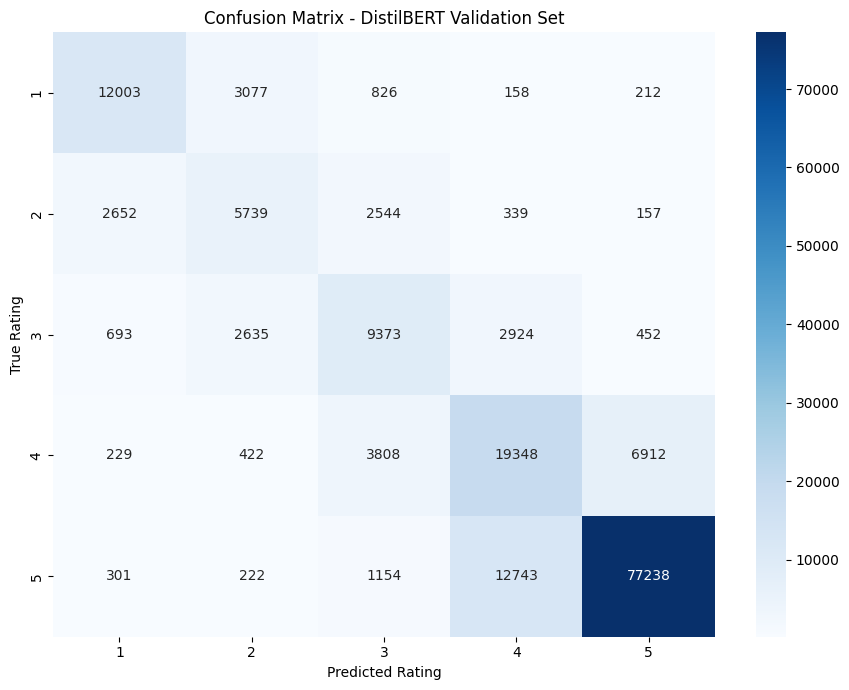

[SUCCESS] Confusion matrix saved to:
/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp/confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["1", "2", "3", "4", "5"],
    yticklabels=["1", "2", "3", "4", "5"]
)

plt.title("Confusion Matrix - DistilBERT Validation Set")
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.tight_layout()

confusion_matrix_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SUCCESS] Confusion matrix saved to:\n{confusion_matrix_path}")


### Confusion Matrix Interpretation

The confusion matrix shows that the model makes most errors between adjacent rating classes rather than between distant classes. For example, reviews with a true rating of 2 are more frequently predicted as 1 or 3, while true rating-4 reviews are commonly predicted as 3 or 5.

This pattern is meaningful because review ratings have an ordinal structure: confusing ratings 4 and 5 is generally less severe than confusing ratings 1 and 5. The strong diagonal values for ratings 1 and 5 indicate that the model can identify highly negative and highly positive reviews relatively well.

The intermediate classes, especially ratings 2 and 3, remain more difficult because their textual sentiment often overlaps with neighboring rating levels. This result is consistent with the lower Macro F1-score compared with the Weighted F1-score.


## Class Distribution Analysis

Before model training, the distribution of review ratings is examined to identify possible class imbalance in the training data.

The chart presents the number of samples for each rating class from 1 to 5. Understanding this distribution is important because an imbalanced dataset may cause a classifier to favor the majority class, reducing performance for less frequent ratings.


/tmp/ipykernel_1296/1068135207.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df_for_plot = pd.read_csv(TRAIN_CSV_PATH)


[INFO] Training data shape: (664451, 16)
[INFO] Columns: ['row_id', 'overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'reviewText_raw', 'reviewText_clean', 'brand', 'title']


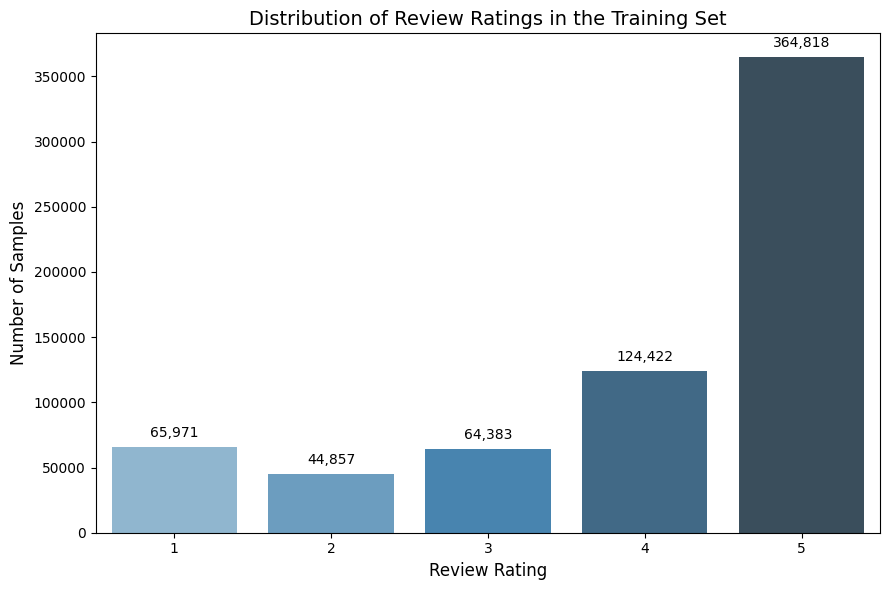


[SUCCESS] Only the chart image was saved here:
/content/drive/MyDrive/AI_Project2 (1)/outputs/nlp/training_class_distribution.png


,count,percentage
rating,,
1,65971,9.93
2,44857,6.75
3,64383,9.69
4,124422,18.73
5,364818,54.91


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read-only: does not modify or delete any existing file.
TRAIN_CSV_PATH = os.path.join(INPUT_DIR, "nlp_train_clean.csv")

train_df_for_plot = pd.read_csv(TRAIN_CSV_PATH)

print("[INFO] Training data shape:", train_df_for_plot.shape)
print("[INFO] Columns:", train_df_for_plot.columns.tolist())

rating_counts = (
    train_df_for_plot["overall"]
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

rating_percentages = (rating_counts / rating_counts.sum() * 100).round(2)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=rating_counts.index.astype(str),
    y=rating_counts.values,
    hue=rating_counts.index.astype(str),
    palette="Blues_d",
    legend=False
)

plt.title("Distribution of Review Ratings in the Training Set", fontsize=14)
plt.xlabel("Review Rating", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

for bar, count in zip(ax.patches, rating_counts.values):
    ax.annotate(
        f"{count:,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()

# Only creates/updates this one image file.
class_distribution_path = os.path.join(
    OUTPUT_DIR,
    "training_class_distribution.png"
)

plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

distribution_summary = pd.DataFrame({
    "count": rating_counts,
    "percentage": rating_percentages
})
distribution_summary.index.name = "rating"

print(f"\n[SUCCESS] Only the chart image was saved here:\n{class_distribution_path}")
display(distribution_summary)


### Distribution Interpretation

The training dataset is noticeably imbalanced across the five rating classes. Rating 5 is the dominant class, accounting for 364,818 samples (54.91%) of the training data. In contrast, rating 2 is the least frequent class, with only 44,857 samples (6.75%).

This imbalance can bias a standard classifier toward predicting the majority class more frequently. Therefore, Weighted Cross-Entropy Loss was used during model fine-tuning to assign greater importance to underrepresented classes and reduce majority-class bias.

The imbalance also helps explain why the weighted F1-score (75.08%) is higher than the macro F1-score (64.96%): the model performs particularly well on the dominant rating-5 class, while the minority and intermediate classes remain more challenging.


# Final Project Conclusion

This project developed an end-to-end natural language processing pipeline for predicting Amazon review ratings from textual review data.

The workflow included data loading, text preprocessing, class-distribution analysis, tokenization, fine-tuning of the `distilbert-base-uncased` transformer model, validation-based evaluation, error analysis, test prediction, and Kaggle submission generation.

## Key Methodological Decisions

- The original ratings from 1 to 5 were converted to internal zero-based labels from 0 to 4 for model training.
- Dynamic padding was used during tokenization to reduce unnecessary computation and memory usage.
- A stratified train-validation split was used to preserve the rating distribution across both datasets.
- The training set showed substantial class imbalance, with rating 5 representing 54.91% of all samples.
- Weighted Cross-Entropy Loss was applied to reduce majority-class bias and improve learning for underrepresented rating classes.
- Macro F1-score was used as the primary model-selection metric because it evaluates all rating classes with equal importance.

## Final Validation Results

The best fine-tuned DistilBERT model achieved the following validation performance:

| Metric | Score |
|---|---:|
| Accuracy | 74.45% |
| Macro F1-score | 64.96% |
| Weighted F1-score | 75.08% |

The model performed particularly well on rating classes 1 and 5, which represent clearly negative and clearly positive reviews. The intermediate rating classes, especially ratings 2 and 3, were more difficult to distinguish because their review text often overlaps semantically with neighboring rating levels.

The confusion matrix showed that most prediction errors occurred between adjacent ratings, such as predicting 4 instead of 5 or 2 instead of 3. This indicates that the model captured the ordinal nature of review ratings to a meaningful extent.

## Final Outputs

The following project artifacts were saved successfully:

- Fine-tuned model and tokenizer:
  `outputs/nlp/best_distilbert_model/`
- Validation metrics:
  `outputs/nlp/validation_metrics.csv`
- Training class-distribution chart:
  `outputs/nlp/training_class_distribution.png`
- Validation confusion matrix:
  `outputs/nlp/confusion_matrix.png`
-  submission file:
  `outputs/nlp/submission.csv`

## Submission Status

The final submission file was verified successfully. It contains 20,000 rows, includes the required `row_id` and `overall` columns, has no missing values or duplicate identifiers, and contains valid predicted ratings between 1 and 5.

